
[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Applying effect: fog on image number 1



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Applying effect: sun_flare on image number 2


C:\Users\Manh Cuong\AppData\Local\Temp\ipykernel_59936\1236622012.py:45: UserWarning: Argument(s) 'angle_lower, angle_upper' are not valid for transform RandomSunFlare
  A.RandomSunFlare(flare_roi=(0, 0, 0.9, 0.9), angle_lower=0.7, angle_upper=1.0, num_flare_circles_range=(2, 6),src_radius=100,src_color=(255, 240, 200),p=1)


Applying effect: sun_flare on image number 3
Applying effect: rain on image number 4
Applying effect: fog on image number 5
Applying effect: rain on image number 6
Applying effect: snow on image number 7
Applying effect: sun_flare on image number 8


C:\Users\Manh Cuong\AppData\Local\Temp\ipykernel_59936\1236622012.py:79: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


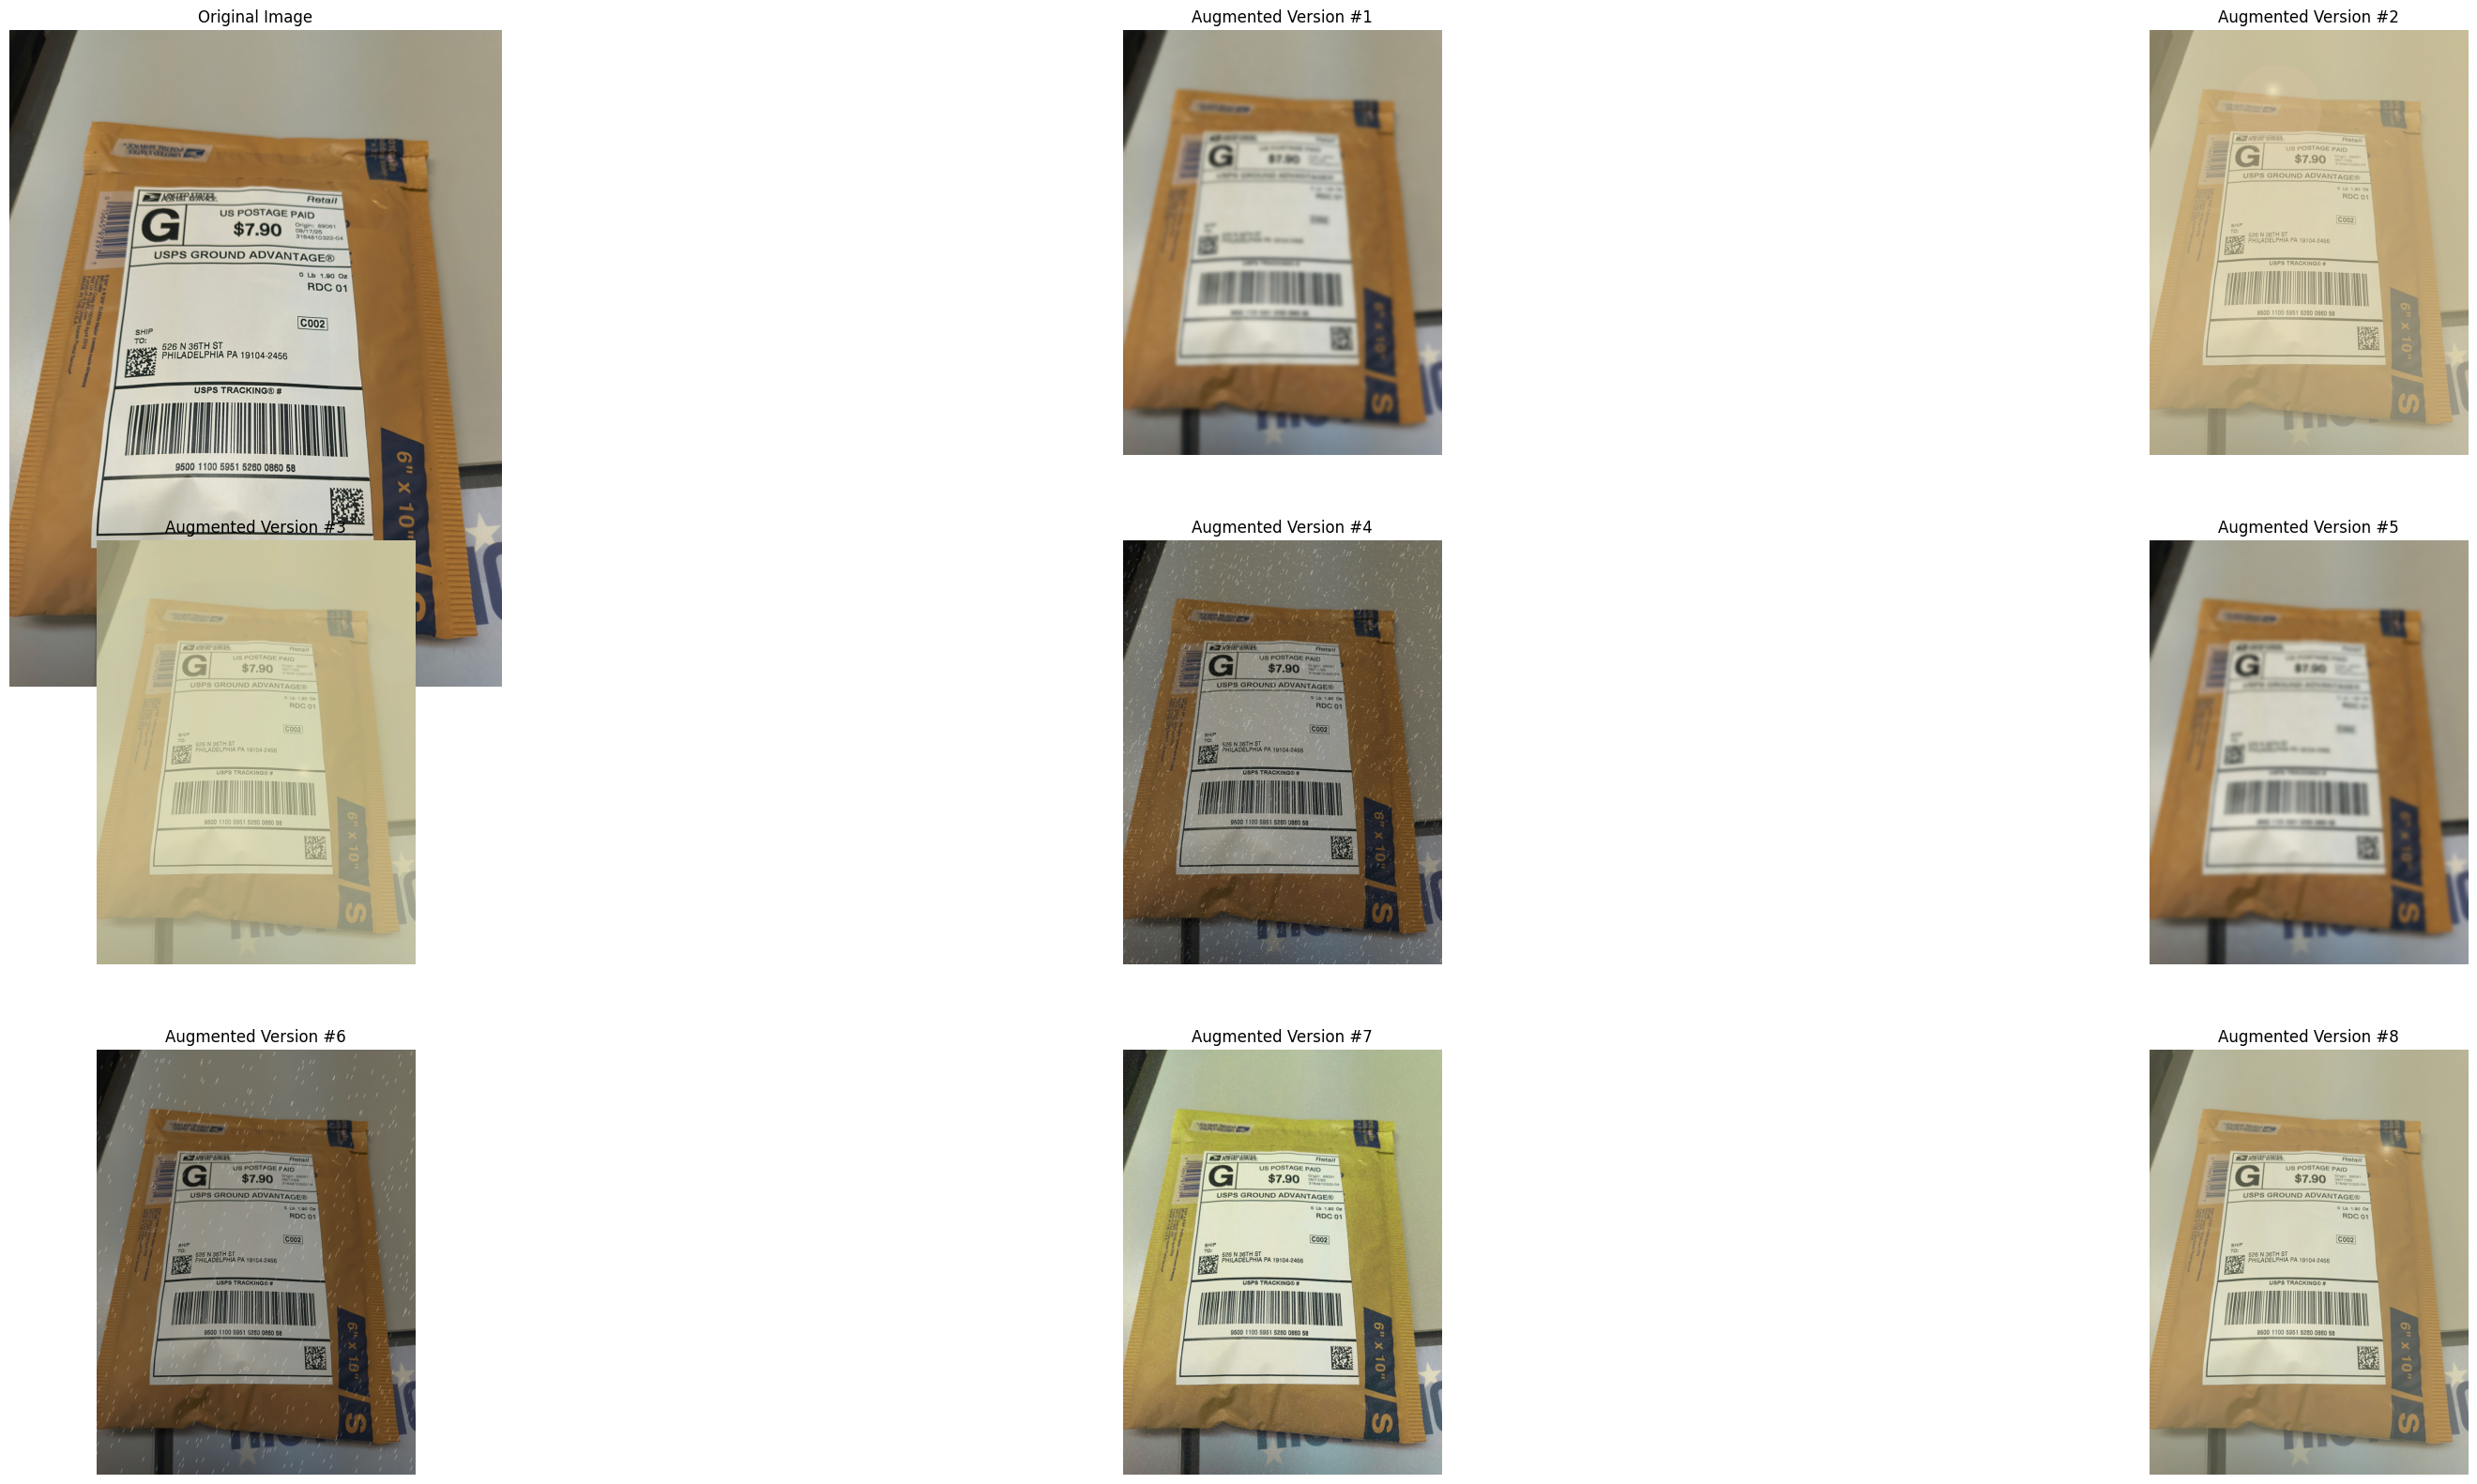

In [ ]:
!pip install opencv-contrib-python
!pip install albumentations

import cv2 # install opencv-python

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load Your Original Image ---
# Make sure to replace 'path/to/your/campus_image.jpg' with an actual file path.
image_path = r'C:\Users\Manh Cuong\Downloads\7746823483387901223.jpg'
try:
    # cv2 reads images in BGR format by default
    original_image = cv2.imread(image_path)
    # Convert BGR to RGB for correct display with matplotlib
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
except:
    print(f"Error: Could not load image from {image_path}")
    # As a fallback, create a simple placeholder image
    # Create a random placeholder image
    original_image_rgb = np.random.randint(0, 255, size=(400, 600, 3), dtype=np.uint8)

# Modify the transform pipeline to include only one weather effect at a time
weather_effects = ["rain", "snow", "fog","sun_flare"]
# Randomly select a weather effect
transform = None

def apply_transform(transform, image,selected_effect = None):
    
    if selected_effect == "rain":
        transform = A.Compose([
            A.Spatter(mode='rain',mean=(0.3,0.65),std=(0.2,0.5), p=1),
            A.RandomRain(drop_length=20, drop_width=1,  blur_value=3, p=1)
        ])
    elif selected_effect == "snow":
        transform = A.Compose([
            A.RandomSnow(snow_point_range=(0.05, 0.2), brightness_coeff=1.25,method="texture", p=1),
            A.RandomSnow(snow_point_range=(0.05, 0.2),method="bleach",p=0.5)
        ])
    elif selected_effect == "fog":
        transform = A.Compose([
            A.RandomFog(fog_coef_range=(0.1, 0.3), p=1)])
    elif selected_effect == "sun_flare":
        transform = A.Compose([
            A.RandomSunFlare(flare_roi=(0, 0, 0.9, 0.9), angle_lower=0.7, angle_upper=1.0, num_flare_circles_range=(2, 6),src_radius=100,src_color=(255, 240, 200),p=1)
        ])
    
    return transform(image=image)



# --- 3. Generate and Visualize Augmented Images ---
# We will generate 4 augmented versions to see the random effects.
num_augmented_images = 8
augmented_images = []
for _ in range(num_augmented_images):
    selected_effect = np.random.choice(weather_effects, p=[0.25, 0.25, 0.25,0.25])
    print(f"Applying effect: {selected_effect} on image number {_+1}")
    # Apply the pipeline to the original image
    augmented = apply_transform(transform,image=original_image_rgb,selected_effect=selected_effect)
    augmented_images.append(augmented['image'])

# Display the original and the new images
plt.figure(figsize=(40, 20))

# Display Original Image
plt.subplot(2, 3, 1)
plt.imshow(original_image_rgb)
plt.title('Original Image')
plt.axis('off')

# Display Augmented Images
for i, aug_image in enumerate(augmented_images):
    plt.subplot(3, 3, i + 2)
    plt.imshow(aug_image)
    plt.title(f'Augmented Version #{i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
!pip install piexif
import os
from tqdm import tqdm
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
import piexif

# Define the directories
input_directory = r"D:\UPenn\CIS-5190\project\data\train\raw"
output_directory = r"D:\UPenn\CIS-5190\project\data\train"

# Ensure the output directory exists
os.makedirs(output_directory, exist_ok=True)

# Enable OpenCV's CUDA support if available
if cv2.cuda.getCudaEnabledDeviceCount() > 0:
    print("Using GPU acceleration with OpenCV.")
    original_image_rgb = cv2.cuda_GpuMat().upload(original_image_rgb)
weather_effects = ["rain", "snow", "fog","sun_flare"]

# Iterate through all images in the input directory
def get_exif_data(image_path):
    """Extract EXIF data from an image."""
    try:
        image = Image.open(image_path)
        exif_data = image._getexif()
        if exif_data is not None:
            return {TAGS.get(tag, tag): value for tag, value in exif_data.items()}
    except Exception as e:
        print(f"Error extracting EXIF data: {e}")
    return {}

def save_with_exif(output_path, image_array, exif_data):
    """Save an image with EXIF data."""
    try:
        image = Image.fromarray(image_array)
        image.save(output_path, exif=exif_data)
    except Exception as e:
        print(f"Error saving image with EXIF data: {e}")

# Extract EXIF data from the original image
original_exif_data = get_exif_data(image_path)

for filename in tqdm(os.listdir(input_directory)):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
        # Load the image
        image_path = os.path.join(input_directory, filename)
        original_image = cv2.imread(image_path)
        original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
        
        try:
            # Extract EXIF data for the current image
            exif_data = piexif.load(image_path)
            
            # Extract GPS coordinates if available
            gps_info = exif_data.get("GPS", {})
            gps_coordinates = {}
            if gps_info:
                for key, val in gps_info.items():
                    tag_name = GPSTAGS.get(key, key)
                    gps_coordinates[tag_name] = val
            
            # Re-encode only GPS data into the byte format needed for saving
            exif_data = {"GPS": gps_info}
            exif_bytes = piexif.dump(exif_data)
        except Exception as e:
            print(f"Error processing EXIF data for {filename}: {e}")
            continue
        # Generate 4 augmented variations for each image
        for i in range(4):
            selected_effect = np.random.choice(weather_effects, p=[0.25, 0.25, 0.25, 0.25])
            augmented = apply_transform(transform, image=original_image_rgb, selected_effect=selected_effect)
            augmented_image = augmented['image']

            # Resize the augmented image to 224x224
            # resized_image = cv2.resize(augmented_image, (224, 224))

            # Save the augmented image with EXIF data
            base_filename, ext = os.path.splitext(filename)
            output_filename = f"{base_filename}_{selected_effect}_{i+1}.jpg"
            output_path = os.path.join(output_directory, output_filename)
            augmented_image = cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR)
            save_with_exif(output_path, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR), exif_bytes)


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Manh Cuong\AppData\Local\Temp\ipykernel_59936\1236622012.py:45: UserWarning: Argument(s) 'angle_lower, angle_upper' are not valid for transform RandomSunFlare
  A.RandomSunFlare(flare_roi=(0, 0, 0.9, 0.9), angle_lower=0.7, angle_upper=1.0, num_flare_circles_range=(2, 6),src_radius=100,src_color=(255, 240, 200),p=1)
100%|██████████| 100/100 [1:10:44<00:00, 42.45s/it]


In [4]:
%jupyter trust r"D:\UPenn\CIS-5190\project\data_generation.ipynb"

UsageError: Line magic function `%jupyter` not found.


# **DATA VISUALIZATION**

In [2]:
%pip install folium pandas
import folium
import pandas as pd
import os
from folium.plugins import MarkerCluster

# --- Configuration ---
# Use the path to your *training* data's metadata
METADATA_CSV_PATH = r"D:\UPenn\CIS-5190\project\data\train\metadata.csv"
OUTPUT_MAP_FILE = "data_coverage_map.html" # It's still good to save a backup

# --- 1. Load Your GPS Data ---
try:
    df = pd.read_csv(METADATA_CSV_PATH)
except FileNotFoundError:
    print(f"Error: Could not find {METADATA_CSV_PATH}")
    # exit() # In a notebook, we can just stop here
    
# Check for the correct column names from your CSV
if 'file_name' not in df.columns:
    print("Error: Could not find 'file_name' column. Please check your metadata.csv.")
if 'Latitude' not in df.columns or 'Longitude' not in df.columns:
    print("Error: 'Latitude' or 'Longitude' columns not found.")
    
# Drop any rows with missing GPS data
df = df.dropna(subset=['Latitude', 'Longitude'])
print(f"Loaded {len(df)} data points from {METADATA_CSV_PATH}")

# --- 2. Calculate the Center of Your Map ---
if not df.empty:
    center_lat = df['Latitude'].mean()
    center_lon = df['Longitude'].mean()
else:
    print("No data to plot.")
    # exit()

# --- 3. Create the Folium Map ---
# This initializes a map centered on your data
m = folium.Map(location=[center_lat, center_lon], zoom_start=17)

# --- 4. Add Your GPS Points to a Cluster ---
print("Clustering GPS points for display...")
# Create a MarkerCluster object to add points to
marker_cluster = MarkerCluster().add_to(m)

# Add points to the cluster object
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        # Add the filename as a popup when you click a dot
        popup=folium.Popup(f"<b>{row['file_name']}</b>", max_width=300)
    ).add_to(m)

# --- 5. Save and Show the Map ---
try:
    m.save(OUTPUT_MAP_FILE)
    print(f"Map file also saved to: {OUTPUT_MAP_FILE}")
except Exception as e:
    print(f"Error saving map: {e}")

# --- 6. Display in Notebook ---
# By having 'm' as the last line, Jupyter will render the map.
print("Rendering map in notebook...")
m

Note: you may need to restart the kernel to use updated packages.
Loaded 400 data points from D:\UPenn\CIS-5190\project\data\train\metadata.csv
Clustering GPS points for display...



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Map file also saved to: data_coverage_map.html
Rendering map in notebook...
